Package Imports

In [8]:
# Import required packages
import pandas as pd
import numpy as np
import seaborn as sns
import datetime
from matplotlib import pyplot as plt

print("Libraries imported successfully!")


Libraries imported successfully!


Read & Clean 2018 Dataset

In [9]:
df = pd.read_csv('eda_structuring_with_python_dataset1.csv')
# covert data column to datetime
df['date'] = pd.to_datetime(df['date'])
# verify initial shape and check for duplicate records
print("Initial Dataset Shape: ", df.shape)
print("Shape after dropping duplicate:",df.drop_duplicates().shape)
df.head(5)

Initial Dataset Shape:  (10000, 3)
Shape after dropping duplicate: (10000, 3)


,date,number_of_strikes,center_point_geom
0,2018-04-13,7,POINT(-114.7 33.3)
1,2018-12-15,12,POINT(-112.9 26.5)
2,2018-09-28,16,POINT(-71.1 29.0)
3,2018-04-17,22,POINT(-90.6 49.0)
4,2018-03-13,31,POINT(-94.5 28.7)


Geographic Locations with Most Strikes (Single Day & Frequency)

In [10]:
# Top 10 single-day strike locations
print("--- TOP 10 LOCATIONS BY STRIKE COUNT IN A SINGLE DAY ---")
display(df.sort_values(by='number_of_strikes', ascending=False).head(10))

# Top 20 locations by total days with at least one strike
print("\n--- TOP 20 LOCATIONS BY FREQUENCY OF STRIKE DAYS ---")
top_locations = (
    df['center_point_geom']
    .value_counts()[:20]
    .rename_axis('unique_values')
    .reset_index(name='counts')
)

top_locations.style.background_gradient(cmap='Blues')

--- TOP 10 LOCATIONS BY STRIKE COUNT IN A SINGLE DAY ---


,date,number_of_strikes,center_point_geom
8582,2018-03-14,190,POINT(-96.8 47.2)
7934,2018-08-23,171,POINT(-107.3 48.6)
3913,2018-06-10,161,POINT(-105.6 21.1)
2891,2018-10-16,153,POINT(-106.9 47.6)
8109,2018-06-30,151,POINT(-110.5 26.1)
4463,2018-04-24,147,POINT(-74.8 27.6)
9636,2018-09-28,142,POINT(-72.2 27.0)
419,2018-12-31,137,POINT(-93.6 43.7)
6016,2018-06-18,136,POINT(-90.7 29.5)
4621,2018-07-12,134,POINT(-119.5 21.8)



--- TOP 20 LOCATIONS BY FREQUENCY OF STRIKE DAYS ---


,unique_values,counts
0,POINT(-83.0 37.7),3
1,POINT(-104.4 22.5),3
2,POINT(-117.7 26.2),3
3,POINT(-96.9 49.6),3
4,POINT(-95.9 31.5),3
5,POINT(-86.6 34.9),3
6,POINT(-117.3 25.0),3
7,POINT(-103.7 34.6),3
8,POINT(-114.7 43.1),3
9,POINT(-90.6 49.0),2


Weekday Feature Extraction & Distribution Analysis

--- MEAN STRIKES PER WEEKDAY ---


,number_of_strikes
weekday,
Friday,20.031142
Monday,20.049391
Saturday,20.288646
Sunday,20.514483
Thursday,20.066330
Tuesday,21.265769
Wednesday,20.138990


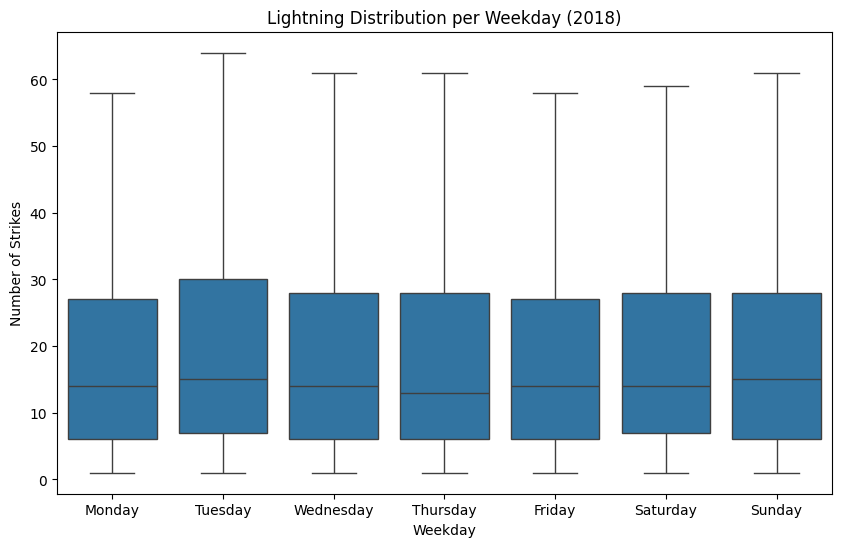

In [11]:
# Extract ISO week and day name
df['week'] = df['date'].dt.isocalendar().week
df['weekday'] = df['date'].dt.day_name()

# Calculate mean strikes per weekday
print("--- MEAN STRIKES PER WEEKDAY ---")
display(df[['weekday', 'number_of_strikes']].groupby('weekday').mean())

# Plot boxplot across weekdays
plt.figure(figsize=(10, 6))
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

g = sns.boxplot(
    data=df,
    x='weekday',
    y='number_of_strikes',
    order=weekday_order,
    showfliers=False
)
g.set_title('Lightning Distribution per Weekday (2018)')
plt.ylabel('Number of Strikes')
plt.xlabel('Weekday')
plt.show()

Merge Multi-Year Datasets (2016–2018)

In [12]:
# Read 2016-2017 dataset
df_2 = pd.read_csv('eda_structuring_with_python_dataset2.csv')
df_2['date'] = pd.to_datetime(df_2['date'])

# Combine datasets while dropping temporary columns from 2018 df
union_df = pd.concat([df.drop(['weekday', 'week'], axis=1), df_2], ignore_index=True)

# Add time unit helper columns
union_df['year'] = union_df['date'].dt.year
union_df['month'] = union_df['date'].dt.month
union_df['month_txt'] = union_df['date'].dt.month_name()

print("--- TOTAL STRIKES BY YEAR ---")
display(union_df[['year', 'number_of_strikes']].groupby('year').sum())

--- TOTAL STRIKES BY YEAR ---


,number_of_strikes
year,
2016,157636
2017,151795
2018,203354


Calculate Monthly Proportions & Visualize Trends

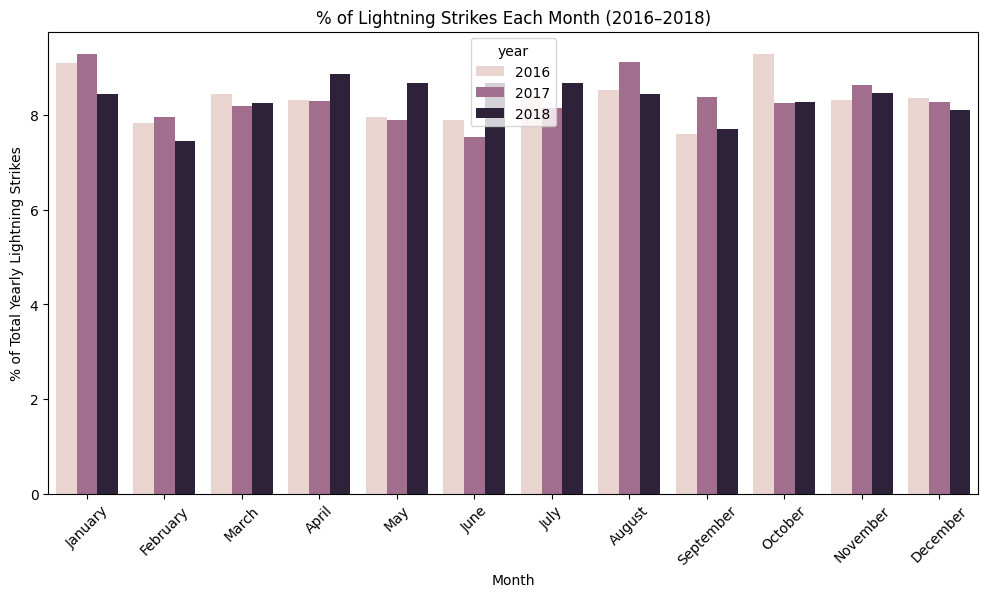

In [13]:
# Calculate total strikes per month per year
lightning_by_month = union_df.groupby(['month_txt', 'year']).agg(
    number_of_strikes=pd.NamedAgg(column='number_of_strikes', aggfunc='sum')
).reset_index()

# Calculate total strikes per year
lightning_by_year = union_df.groupby('year').agg(
    year_strikes=pd.NamedAgg(column='number_of_strikes', aggfunc='sum')
).reset_index()

# Merge monthly and annual totals
percentage_lightning = lightning_by_month.merge(lightning_by_year, on='year')

# Calculate percentage column
percentage_lightning['percentage_lightning_per_month'] = (
    percentage_lightning['number_of_strikes'] / percentage_lightning['year_strikes'] * 100.0
)

# Plot monthly proportions across years
plt.figure(figsize=(12, 6))
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

sns.barplot(
    data=percentage_lightning,
    x='month_txt',
    y='percentage_lightning_per_month',
    hue='year',
    order=month_order
)

plt.xlabel("Month")
plt.ylabel("% of Total Yearly Lightning Strikes")
plt.title("% of Lightning Strikes Each Month (2016–2018)")
plt.xticks(rotation=45)
plt.show()